In [2]:
import pandas as pd
df = pd.read_csv('2) Stock Prices Data Set.csv')
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [4]:
print(df.isnull().sum())


symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


In [5]:
print(df.duplicated().sum())

0


In [6]:
df.dropna(inplace=True)

In [7]:
print(df.isnull().sum())

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 497461 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497461 non-null  str           
 1   date    497461 non-null  datetime64[us]
 2   open    497461 non-null  float64       
 3   high    497461 non-null  float64       
 4   low     497461 non-null  float64       
 5   close   497461 non-null  float64       
 6   volume  497461 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 30.4 MB


In [19]:
df.describe()

,date,open,high,low,close,volume
count,497461,497461.000000,497461.000000,497461.000000,497461.000000,4.974610e+05
mean,2016-01-06 17:16:56.524311,86.352275,87.132717,85.552616,86.368586,4.253695e+06
min,2014-01-02 00:00:00,1.620000,1.690000,1.500000,1.590000,1.010000e+02
25%,2015-01-08 00:00:00,41.690000,42.090000,41.280000,41.700000,1.080183e+06
50%,2016-01-11 00:00:00,64.970000,65.560000,64.357400,64.980000,2.085013e+06
75%,2017-01-06 00:00:00,98.410000,99.230000,97.580000,98.420000,4.271999e+06
max,2017-12-29 00:00:00,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08
std,NaN,101.471228,102.312340,100.571231,101.471516,8.232210e+06


In [28]:
pd.options.display.float_format = '{:.2f}'.format
df.mean(numeric_only=True)

open          86.35
high          87.13
low           85.55
close         86.37
volume   4253694.67
dtype: float64

In [29]:
df.median(numeric_only=True)

open          64.97
high          65.56
low           64.36
close         64.98
volume   2085013.00
dtype: float64

In [24]:
df.mode(numeric_only=True)

,open,high,low,close,volume
0,70.0,72.0,77.0,34.5,1241019


In [30]:
pd.options.display.float_format = '{:.2f}'.format
df.std(numeric_only=True)

open         101.47
high         102.31
low          100.57
close        101.47
volume   8232210.33
dtype: float64

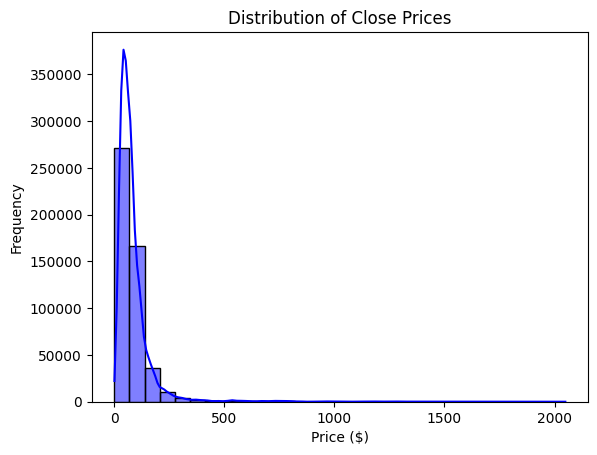

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pylab as plt
import seaborn as sns
sns.histplot(df['close'], kde=True, color='blue', bins=30)
plt.title('Distribution of Close Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')       
plt.show()
plt.savefig('distribution_plot.png', dpi=300)

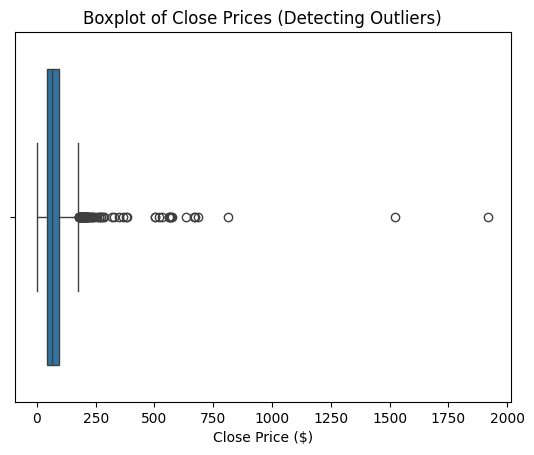

<Figure size 640x480 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 
df_sample = df.sample(1000)
sns.boxplot(x=df_sample ['close'])
plt.title('Boxplot of Close Prices (Detecting Outliers)')
plt.xlabel('Close Price ($)')
plt.show()
plt.savefig('outliers_boxplot.png', dpi=300)

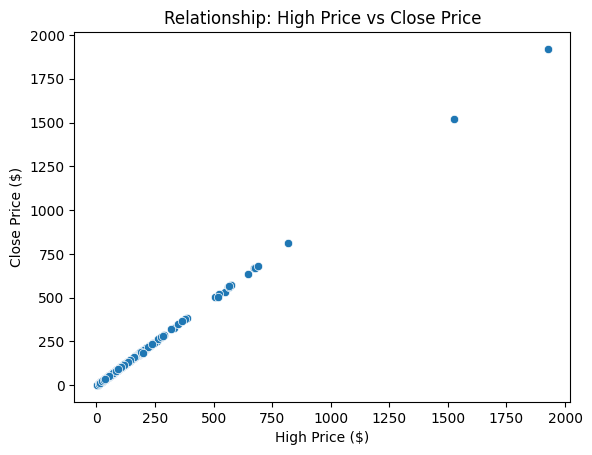

In [12]:
sns.scatterplot(x='high', y='close', data=df_sample)
plt.title('Relationship: High Price vs Close Price')
plt.xlabel('High Price ($)')
plt.ylabel('Close Price ($)')
plt.show()

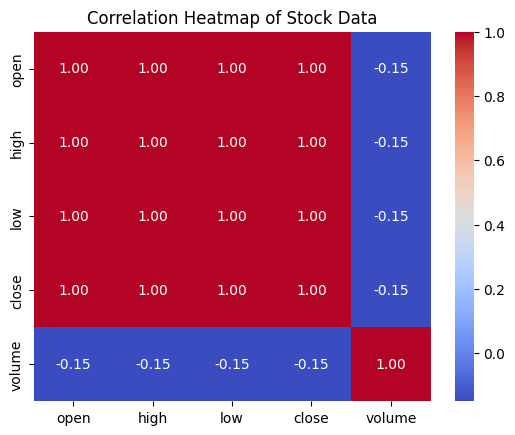

<Figure size 640x480 with 0 Axes>

In [13]:
Matrix= df.corr(numeric_only=True)
sns.heatmap(Matrix,annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Stock Data')
plt.show()
plt.savefig('correlation_heatmap.png', dpi=300)